In [1]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
from functools import partial
from einops import rearrange
from scipy.interpolate import RectBivariateSpline
from scipy.ndimage import gaussian_filter
from tqdm.notebook import tqdm

import sys
sys.path.append("../")

from utils import create_mask as cm
from utils.pdf_sampler import PDFSampler
from models.psf import KingPSF

%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pylab as pylab
import warnings
import matplotlib.cbook

from plot_params import params

warnings.filterwarnings("ignore",category=matplotlib.cbook.mplDeprecation)

pylab.rcParams.update(params)
cols_default = plt.rcParams['axes.prop_cycle'].by_key()['color']

In [3]:
from reproject import reproject_from_healpix, reproject_to_healpix
from astropy.wcs import WCS
from astropy.coordinates import ICRS, Galactic

In [4]:
from utils.cart import make_wcs, to_cart

In [5]:
# from torchinfo import summary

In [6]:
cmap = 'RdBu_r'

In [7]:
! nvidia-smi

Thu May 26 11:39:22 2022       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 470.57.02    Driver Version: 470.57.02    CUDA Version: 11.4     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  Tesla V100-PCIE...  On   | 00000000:06:00.0 Off |                    0 |
| N/A   40C    P0    42W / 250W |      0MiB / 32510MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
                                                                               
+-------

In [8]:
extent = 25
n_pixels = 100
pixelsize = 2 * extent / n_pixels
upsample_factor = 4
nside = 128
sigma_psf = 0.2

In [9]:
fermi_data_cart = to_cart(np.load("../data/fermi_data/fermidata_counts.npy"), n_pixels=n_pixels, pixelsize=pixelsize)

# Load standard templates
temp_gce_cart = to_cart(np.load("../data/fermi_data/template_gce.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
temp_dif_cart = to_cart(np.load("../data/fermi_data/template_dif.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
temp_psc_cart = to_cart(np.load("../data/fermi_data/template_psc.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
temp_iso_cart = to_cart(np.load("../data/fermi_data/template_iso.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
temp_dsk_cart = to_cart(np.load("../data/fermi_data/template_dsk.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
temp_bub_cart = to_cart(np.load("../data/fermi_data/template_bub.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
mask_ps = np.load("../data/fermi_data/fermidata_pscmask.npy") == 1

# Load Model O templates
temp_mO_pibrem_cart = to_cart(np.load("../data/fermi_data/ModelO_r25_q1_pibrem.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
temp_mO_ics_cart = to_cart(np.load("../data/fermi_data/ModelO_r25_q1_ics.npy"), n_pixels=n_pixels, pixelsize=pixelsize)

mask_roi = to_cart(cm.make_mask_total(nside=nside, band_mask=True, band_mask_range=2., mask_ring=True, inner=0, outer=60., custom_mask=mask_ps), n_pixels=n_pixels, pixelsize=pixelsize) > 0
mask_plane = to_cart(cm.make_mask_total(nside=nside, band_mask=True, band_mask_range=2., mask_ring=True, inner=0, outer=60.,), n_pixels=n_pixels, pixelsize=pixelsize) > 0

In [10]:
np.save("../data/fermi_data/mask_roi.npy", mask_roi)
np.save("../data/fermi_data/mask_plane.npy", mask_plane)

## Generative model

In [11]:
from models.glow_module import GlowPL
import torch

/n/home11/smsharma/.local/lib/python3.8/site-packages/horovod/common/util.py:258: UserWarning: Framework pytorch installed with version 1.11.0+cu102 but found version 1.11.0+cu113.
             This can result in unexpected behavior including runtime errors.
             Reinstall Horovod using `pip install --no-cache-dir` to build with the new version.
  warnings.warn(get_version_mismatch_message(name, version, installed_version))


In [12]:
x = np.load("../data/samples/x_train_14.npy")

In [13]:
np.max(x * ~mask_roi)

214.0

In [14]:
x = torch.Tensor(x)[:, 2:-2, 2:-2].unsqueeze(1)

In [15]:
model = GlowPL(num_channels=256, num_levels=5, num_steps=18, quants=1000, add_unif_noise=True)

../models/glow.py:102: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at  ../torch/csrc/utils/tensor_numpy.cpp:178.)
  w_s = torch.from_numpy(w_s)


In [16]:
model.flow.load_state_dict(torch.load("../data/logs/wandb/run-20220514_063818-qz7p9m0f/files/flow.ckpt"))
model.flow.eval();

In [17]:
def calc_z_shapes(n_channel=1, input_size=96, n_flow=18, n_block=5):
    z_shapes = []

    for i in range(n_block - 1):
        
        input_size //= 2
        n_channel *= 2

        z_shapes.append((n_channel, input_size, input_size))

    input_size //= 2
    z_shapes.append((n_channel * 4, input_size, input_size))

    return z_shapes

In [18]:
model.to('cuda');

In [19]:
from tqdm import tqdm

In [20]:
n_samples = 50

x_samples = []

for _ in tqdm(range(10)):
    z_sample = []
    z_shapes = calc_z_shapes()
    for z in z_shapes:
        z_new = torch.randn(n_samples, *z)
        z_sample.append(z_new.to('cuda'))

    x_samples_temp = (model.flow.reverse(z_sample, reconstruct=False, quant_int=True))
    x_samples.append(x_samples_temp)

100%|██████████| 10/10 [00:01<00:00,  5.81it/s]


In [21]:
x_samples = torch.cat(x_samples)
x_samples = x_samples.cpu()

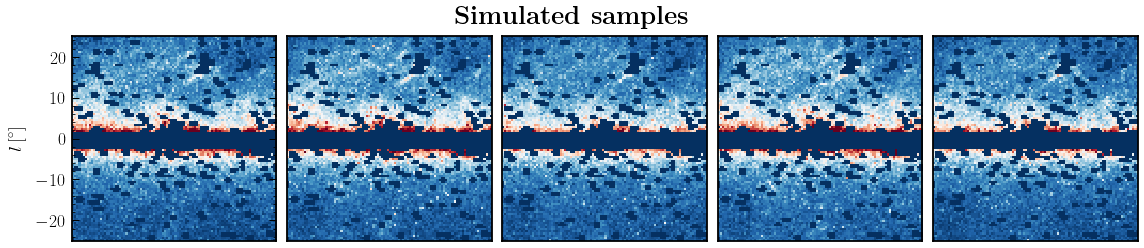

In [22]:
fig, axs = plt.subplots(1, 5, figsize=(16, 4))

for i, ax in enumerate(axs):
    ax.imshow(x[i,0].detach().numpy() * ~mask_roi[2:-2, 2:-2] , cmap=cmap, vmax=100, origin='lower', extent=[-25, 25, -25, 25])
    if i == 0:
        ax.set_ylabel(r"$l\,[^\circ]$")
        ax.get_xaxis().set_visible(False)
    if i != 0:
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

plt.suptitle(r"\textbf{Simulated samples}", fontsize=26, y=0.9)
plt.tight_layout()
# plt.savefig("../paper/samples_sim.pdf")

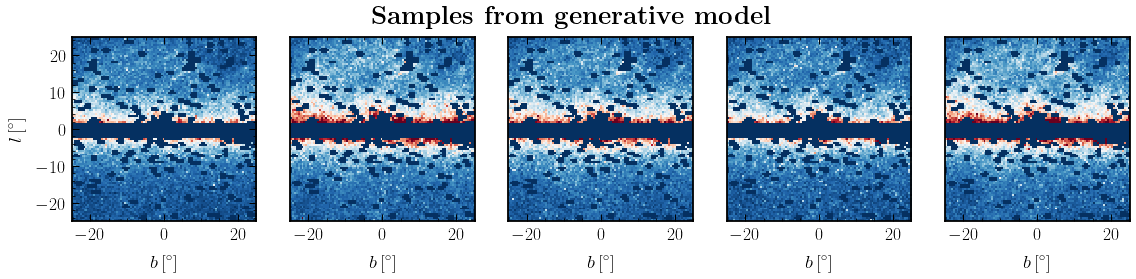

In [23]:
fig, axs = plt.subplots(1, 5, figsize=(16, 4))

for i, ax in enumerate(axs):
    ax.imshow(x_samples[i,0].detach().numpy() * ~mask_roi[2:-2, 2:-2], cmap=cmap, vmax=100, origin='lower', extent=[-25, 25, -25, 25])
    if i == 0:
        ax.set_ylabel(r"$l\,[^\circ]$")
        ax.set_xlabel(r"$b\,[^\circ]$")
    if i != 0:
        ax.set_xlabel(r"$b\,[^\circ]$")
        ax.get_yaxis().set_visible(False)

plt.suptitle(r"\textbf{Samples from generative model}", fontsize=26, y=0.9)
plt.tight_layout()
# plt.savefig("../paper/samples_gen.pdf")

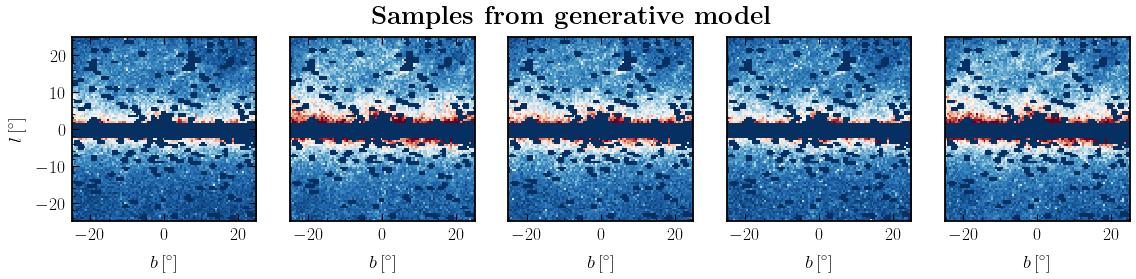

In [24]:
fig, axs = plt.subplots(1, 5, figsize=(16, 4))

for i, ax in enumerate(axs):
    ax.imshow(x_samples[i,0].detach().numpy(), cmap=cmap, vmax=100, origin='lower', extent=[-25, 25, -25, 25])
    if i == 0:
        ax.set_ylabel(r"$l\,[^\circ]$")
        ax.set_xlabel(r"$b\,[^\circ]$")
    if i != 0:
        ax.set_xlabel(r"$b\,[^\circ]$")
        ax.get_yaxis().set_visible(False)

plt.suptitle(r"\textbf{Samples from generative model}", fontsize=26, y=0.9)
plt.tight_layout()
# plt.savefig("../paper/samples_gen.pdf")

## Test summaries

In [25]:
from scipy import stats

def power_spectrum(x):
    """ Power spectrum of map. Adapted from https://bertvandenbroucke.netlify.app/2019/05/24/computing-a-power-spectrum-in-python/
    """
    
    npix = x.shape[0]

    fourier_image = np.fft.fftn(x)
    fourier_amplitudes = np.abs(fourier_image)**2

    kfreq = np.fft.fftfreq(npix) * npix
    kfreq2D = np.meshgrid(kfreq, kfreq)
    knrm = np.sqrt(kfreq2D[0]**2 + kfreq2D[1]**2)

    knrm = knrm.flatten()
    fourier_amplitudes = fourier_amplitudes.flatten()

    kbins = np.arange(0.5, npix//2+1, 1.)
    kvals = 0.5 * (kbins[1:] + kbins[:-1])
    Abins, _, _ = stats.binned_statistic(knrm, fourier_amplitudes,
                                         statistic = "mean",
                                         bins = kbins)
    Abins *= np.pi * (kbins[1:]**2 - kbins[:-1]**2)
    
    return Abins

def counts_histogram(x, counts_max=128):
    bins_hist = np.arange(counts_max)
    return np.histogram(x, bins=bins_hist)[0]

In [26]:
x_pspec_samples = np.array([power_spectrum(x_i) for x_i in x_samples[:, 0, :, :]])
x_pspec_train = np.array([power_spectrum(x_i * ~mask_roi[2:-2, 2:-2]) for x_i in x[:500, 0]])

x_hist_samples = np.array([counts_histogram(x_i) for x_i in x_samples])
x_hist_train = np.array([counts_histogram(x_i * ~mask_roi[2:-2, 2:-2]) for x_i in x[:500, 0]])

findfont: Font family ['serif'] not found. Falling back to DejaVu Sans.


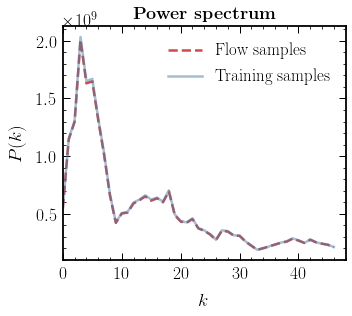

In [27]:
fig, axs = plt.subplots(figsize=(5, 4.5))

plt.plot(np.nanmean(x_pspec_samples, axis=0)[1:], label="Flow samples", ls='--')
plt.plot(np.mean(x_pspec_train, axis=0)[1:], label="Training samples", alpha=0.5)

# plt.fill_between(np.arange(x_pspec_train.shape[-1] - 1), np.percentile(x_pspec_train, [16], axis=0)[0, 1:], np.percentile(x_pspec_train, [84], axis=0)[0, 1:], alpha=0.5, color=cols_default[0])
# plt.fill_between(np.arange(x_pspec_samples.shape[-1] - 1), np.percentile(x_pspec_samples, [16], axis=0)[0, 1:], np.percentile(x_pspec_train, [84], axis=0)[0, 1:], alpha=0.5, color=cols_default[1])

plt.xlabel("$k$")
plt.ylabel("$P(k)$")
plt.title(r"\textbf{Power spectrum}")
         
plt.xlim(0, x_pspec_samples.shape[-1])

plt.legend()

plt.tight_layout()
# plt.savefig("../paper/power_spectrum.pdf")

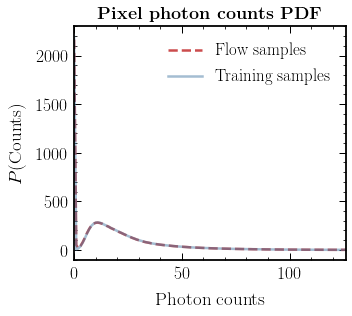

In [28]:
fig, axs = plt.subplots(figsize=(5, 4.5))

plt.plot(np.nanmean(x_hist_samples, axis=0), label="Flow samples", ls='--')
plt.plot(np.mean(x_hist_train, axis=0), label="Training samples", alpha=0.5)

plt.xlabel("Photon counts")
plt.ylabel(r"$P(\mathrm{Counts})$")
plt.title(r"\textbf{Pixel photon counts PDF}")
         
plt.legend()

plt.xlim(0, np.mean(x_hist_train, axis=0).shape[-1]-1)

plt.tight_layout()
# plt.savefig("../paper/counts_pdf.pdf")

## Real data (dragons)

In [29]:
from astropy.io import fits

counts_fits = fits.open("/n/holyscratch01/iaifi_lab/yitians/ccube_ultracleanveto_bestpsf_joined.fits")

pixel_size_data = 0.1
pixel_size_target = 0.5
extent = 25
i_e = 40

upsample_factor = int(pixel_size_target / pixel_size_data)

counts = counts_fits[0].data[i_e:i_e + 11].sum(0)[int((90 - extent) / 0.1):int((90 + extent) / 0.1),int((90 - extent) / 0.1):int((90 + extent) / 0.1)]
b = counts.shape[0] // upsample_factor
counts_downsampled = counts.reshape(-1, upsample_factor, b, upsample_factor).sum((-1, -3))

In [30]:
x_data = torch.Tensor(counts_downsampled)[2:-2, 2:-2].unsqueeze(0).unsqueeze(0)

In [31]:
x_test = np.load("../data/samples/x_test.npy")
x_test = torch.Tensor(x_test)[:, 2:-2, 2:-2]

In [32]:
n_sims = 100

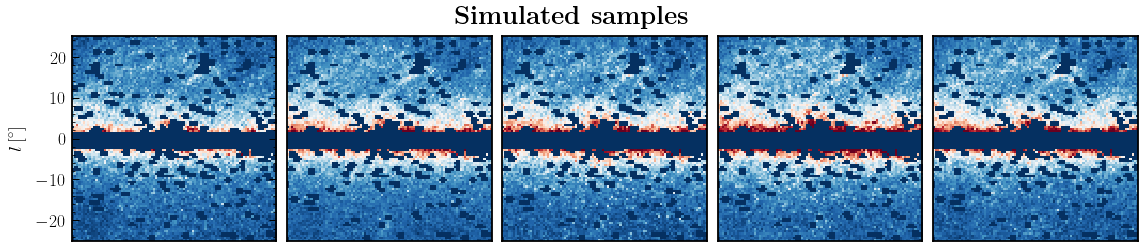

In [33]:
fig, axs = plt.subplots(1, 5, figsize=(16, 4))

for i, ax in enumerate(axs):
    ax.imshow(x_test[i].detach().numpy() * ~mask_roi[2:-2, 2:-2] , cmap=cmap, vmax=100, origin='lower', extent=[-25, 25, -25, 25])
    if i == 0:
        ax.set_ylabel(r"$l\,[^\circ]$")
        ax.get_xaxis().set_visible(False)
    if i != 0:
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

plt.suptitle(r"\textbf{Simulated samples}", fontsize=26, y=0.9)
plt.tight_layout()

Text(0.5, 1.0, '\\textbf{Data}')

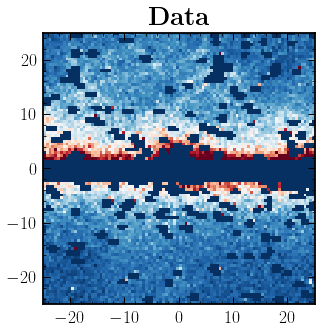

In [34]:
plt.imshow(x_data[0,0].detach().numpy() * ~mask_roi[2:-2, 2:-2] , cmap=cmap, vmax=100, origin='lower', extent=[-25, 25, -25, 25])
plt.title(r"\textbf{Data}", fontsize=26)

### Look at distribution of likelihoods with ROI mask

In [43]:
log_p_sum, logdet_plus_sldj, z = model.flow((x_data * ~mask_roi[2:-2, 2:-2]).to('cuda'))
data = log_p_sum + logdet_plus_sldj

In [41]:
log_p_sum, logdet_plus_sldj, z = model.flow((x_test[:n_sims] * ~mask_roi[2:-2, 2:-2]).unsqueeze(1).to('cuda'))
sims = log_p_sum + logdet_plus_sldj

In [51]:
npix = (~mask_roi[2:-2, 2:-2]).sum()

/n/sw/eb/apps/centos7/Anaconda3/2020.11/lib/python3.8/site-packages/matplotlib/cbook/__init__.py:1289: FutureWarning: The input object of type 'Tensor' is an array-like implementing one of the corresponding protocols (`__array__`, `__array_interface__` or `__array_struct__`); but not a sequence (or 0-D). In the future, this object will be coerced as if it was first converted using `np.array(obj)`. To retain the old behaviour, you have to either modify the type 'Tensor', or assign to an empty array created with `np.empty(correct_shape, dtype=object)`.
  return np.asarray(x, float)


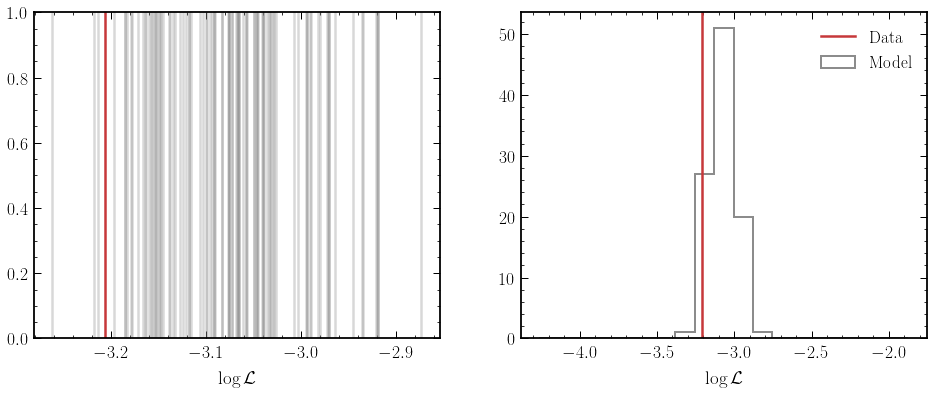

In [56]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

for sim in sims.detach().cpu():
    ax[0].axvline(sim / npix, color='grey', alpha=0.3)

ax[0].axvline(data.detach().cpu() / npix)
ax[0].set_xlabel(r"$\log\mathcal L$")

ax[1].hist(sims.detach().cpu().numpy() / npix, bins=np.linspace(np.min(sims.detach().cpu().numpy()  / npix  - 1), np.max(sims.detach().cpu().numpy()  / npix) + 1, 20), histtype='step', color='grey', label="Model", lw=2)
ax[1].axvline(data.detach().cpu() / npix, label="Data")
ax[1].set_xlabel(r"$\log\mathcal L$")
ax[1].legend()